In [79]:
# !pip install ipywidgets

In [ ]:
import os
from pathlib import Path
import amulet
from tqdm.notebook import tqdm
import random
from collections import defaultdict, Counter

random.seed(1984)



blocks_counter = Counter()

directory = Path("../../data/")

files = [directory / "train" / file  for file in os.listdir(directory / "train")] + \
    [directory / "new_train" / file for file in os.listdir(directory / "new_train")]
random.shuffle(files)

limit = len(files)

for i, file in enumerate(tqdm(files, total=limit)):
    if i >= limit:
        break
    path = file
    try:
        construction = amulet.load_level(str(path))
        dimension = construction.dimensions[0]
        selection = construction.bounds(dimension)
        for coords in selection.blocks:
            block = construction.get_block(*coords, dimension)
            blocks_counter[block.base_name] += 1
    except Exception as e:
        print()
        print(path)
        print(e)



In [82]:
print(f"Total blocks: {len(blocks_counter)}")
print(f"Total amount: {blocks_counter.total()}")
print(f"20 Most common:")
print(*blocks_counter.most_common(20), sep="\n")

Total blocks: 199
Total amount: 1326534979
20 Most common:
('air', 773106967)
('stone', 199231915)
('water', 159206600)
('dirt', 68970173)
('leaves', 22784219)
('grass_block', 20860194)
('sand', 12786186)
('sandstone', 11164474)
('andesite', 5355447)
('stained_terracotta', 5221685)
('diorite', 5213107)
('granite', 5096926)
('terracotta', 4663477)
('gravel', 4544074)
('packed_ice', 3190483)
('log', 3093803)
('plant', 2862268)
('coal_ore', 2787606)
('deepslate', 2651586)
('snow', 2223133)


In [83]:
minus_counter = Counter({key: -value for key, value in blocks_counter.items()})

minus_counter.most_common(20)

[('stained_glass', -1),
 ('sculk_shrieker', -1),
 ('coal_block', -2),
 ('hanging_roots', -3),
 ('smithing_table', -4),
 ('polished_basalt', -4),
 ('wall_sign', -4),
 ('jack_o_lantern', -4),
 ('sculk_catalyst', -6),
 ('lever', -7),
 ('carved_pumpkin', -8),
 ('smoker', -9),
 ('cracked_deepslate_tiles', -9),
 ('fletching_table', -9),
 ('cobbled_deepslate', -10),
 ('barrel', -11),
 ('lectern', -13),
 ('redstone_torch', -13),
 ('raw_iron_block', -13),
 ('campfire', -13)]

In [84]:
world_blocks_counter = blocks_counter
world_block_set = set(blocks_counter.keys())

Разобраться с дефольными атрибутами и зафиксировать финальный набор

Глянуть распределение атрибутов в мирах

Несколько вариантов кодирования блоков + атрибутов

СОхранить json всех блоков

# Раскинуть файлы по папкам

In [2]:
import os
from pathlib import Path
from tqdm import tqdm
import os

data_dir = Path("../../data/web_data/")


extensions = [".schematic", ".schem", ".litematic"]

In [ ]:
for ex in extensions:
    os.makedirs(data_dir / ex[1:], exist_ok=True)


for file in os.listdir(data_dir):
    file_path = data_dir / file
    if file_path.suffix in extensions:
        os.rename(file_path, data_dir / file_path.suffix[1:] / file)

## запустил скрипты


In [ ]:
for file in tqdm(os.listdir(data_dir / "litematic")):
    file_path = data_dir / "litematic" / file
    if file_path.suffix == ".schem":
        os.rename(file_path, data_dir / "schem" / file)

100%|██████████| 4064/4064 [00:08<00:00, 463.05it/s]


In [11]:
count = 0
for file in tqdm(os.listdir(data_dir / "schematic")):
    file_path = data_dir / "schematic" / file
    if file_path.suffix == ".schem":
        count += 1
        os.rename(file_path, data_dir / "schem" / file)
print(count)

100%|██████████| 11215/11215 [00:00<00:00, 144811.05it/s]

4


In [8]:
import nbtlib


schem = nbtlib.load(data_dir / "schem_py_2" / "100.schem")

In [17]:
schem["Schematic"]["Length"]

Short(30)

In [18]:
schem = nbtlib.load(data_dir / "schem" / "100.schem")

In [19]:
schem.keys()

dict_keys(['Version', 'DataVersion', 'Width', 'Height', 'Length', 'Palette', 'BlockData'])

## считаем статистики по schem_all

In [ ]:
import os
from pathlib import Path
import amulet
import json
from tqdm.notebook import tqdm
import random
from collections import defaultdict, Counter
from logging import Logger
import numpy as np

random.seed(1984)
np.random.seed(1984)

with open("../block_data/filtered_blocks.json") as f:
    filtered_blocks = json.load(f)


blocks_counter = Counter()
non_existing_blocks_fraction = []

directory = Path("../../data/web_data/schem_all")

shapes = []

files = os.listdir(directory)
np.random.shuffle(files)

limit = len(files)

success_count = 0
for i, file in enumerate(tqdm(files, total=limit)):
    if i >= limit:
        break
    path = directory / file
    try:
        non_existing_blocks_count = 0
        construction = amulet.load_level(str(path))
        dimension = construction.dimensions[0]
        selection = construction.bounds(dimension)
        bounds_array = selection.bounds_array
        shape = np.abs(bounds_array[0] - bounds_array[1])

        for coords in selection.blocks:
            block = construction.get_block(*coords, dimension).base_name
            if f"minecraft:{block}" in filtered_blocks:
                blocks_counter[block] += 1
            else:
                blocks_counter["air"] += 1
                non_existing_blocks_count += 1

        shapes.append(shape[None, :])
        non_existing_blocks_fraction.append(non_existing_blocks_count / np.prod(shape))
        success_count += 1
        construction.close()
    except Exception as e:
        print(f"Error: {e}\nFile: {file}")
        continue

shapes = np.concatenate(shapes, axis=0)

In [2]:
non_existing_blocks_fraction = np.array(non_existing_blocks_fraction)

In [6]:
len(non_existing_blocks_fraction[non_existing_blocks_fraction < 0.1])

2012

In [4]:
print(f"Successfully opened: {success_count} / {limit} schematics")
print(f"Allowed size schematics: {np.sum(np.prod(shapes <= 64, axis=1) * np.prod(shapes >= 8, axis=1))}")
print(f"Schematics with less than 10% of non-existing blocks: {np.sum(non_existing_blocks_fraction < 0.1)}")
print(f"Final schematics count: {np.sum(np.prod(shapes <= 64, axis=1) * np.prod(shapes >= 8, axis=1) * (non_existing_blocks_fraction < 0.1))}")

Successfully opened: 3202 / 3368 schematics
Allowed size schematics: 1723
Schematics with less than 10% of non-existing blocks: 2012
Final schematics count: 942


In [9]:
np.sum(np.prod(shapes <= 64, axis=1) * np.prod(shapes >= 8, axis=1) * (non_existing_blocks_fraction < 0.1)) / success_count

0.2941911305434104

In [3]:
print(f"Min x,y,z: {shapes.min(axis = 0)}")
print(f"Max x,y,z: {shapes.max(axis = 0)}")
print(f"Mean x,y,z: {shapes.mean(axis = 0)}")
print(f"Median x,y,z: {np.median(shapes,axis=0)}")

Min x,y,z: [8 8 8]
Max x,y,z: [701 384 802]
Mean x,y,z: [55.99367089 48.39389427 55.95085629]
Median x,y,z: [34. 30. 33.]


In [4]:
volumes: np.ndarray = np.prod(shapes, axis=1)

print(f"Min Volume: {volumes.min()}")
print(f"Max Volume: {volumes.max()}")
print(f"Mean Volume: {volumes.mean()}")
print(f"Median Volume: {np.median(volumes)}")

Min Volume: 512
Max Volume: 76562780
Mean Volume: 787324.2271034996
Median Volume: 35695.0


In [5]:
print(f"Uniqie blocks: {len(blocks_counter)}")
print(f"Total amount: {blocks_counter.total()}")
print(f"20 Most common:")
print(*blocks_counter.most_common(20), sep="\n")

Uniqie blocks: 296
Total amount: 2102356103
20 Most common:
('air', 1922235719)
('stone', 70670320)
('dirt', 26055799)
('water', 16632143)
('sandstone', 5654289)
('andesite', 5042665)
('cobblestone', 4884978)
('grass_block', 4306725)
('stone_bricks', 4226111)
('diorite', 3357897)
('granite', 3156999)
('gravel', 2139741)
('sand', 2017379)
('quartz_block', 1845150)
('coarse_dirt', 1562523)
('smooth_stone', 1531513)
('netherrack', 1463573)
('nether_portal', 1389186)
('obsidian', 1194821)
('smooth_quartz', 1146389)


In [6]:
print(f"20 Least common:")

minus_counter = Counter({key: -value for key, value in blocks_counter.items()})

minus_counter.most_common(20)

20 Least common:


[('smooth_quartz_slab', -9),
 ('candle_cake', -10),
 ('calibrated_sculk_sensor', -13),
 ('sculk_shrieker', -18),
 ('smooth_quartz_stairs', -18),
 ('sculk_catalyst', -20),
 ('conduit', -32),
 ('pitcher_crop', -67),
 ('sculk_sensor', -116),
 ('respawn_anchor', -136),
 ('bamboo_sapling', -137),
 ('medium_amethyst_bud', -180),
 ('crimson_fungus', -183),
 ('light_weighted_pressure_plate', -193),
 ('nether_sprouts', -212),
 ('powder_snow', -229),
 ('mangrove_propagule', -234),
 ('warped_roots', -249),
 ('suspicious_sand', -253),
 ('twisting_vines', -258)]

In [91]:
web_blocks_counter = blocks_counter
web_blocks_set = set(web_blocks_counter.keys())

In [92]:
world_blocks_counter
world_block_set;

In [93]:
print(f"Web blocks: {len(web_blocks_set)}")
print(f"World blocks: {len(world_block_set)}")
print(f"Common blocks: {len(web_blocks_set & world_block_set)}")

Web blocks: 297
World blocks: 199
Common blocks: 165


In [94]:
mask = shapes < np.array([64, 64, 64])[None, :]
mask = np.prod(mask.astype(np.int32), axis=1)

print(f"Shapes in 64^3: {mask.sum()} / {limit}")

Shapes in 64^3: 2167 / 3368


In [19]:
2167 - 523

1644

In [14]:
non_existing_blocks_fraction = np.array(non_existing_blocks_fraction)

In [8]:
len(non_existing_blocks_fraction[non_existing_blocks_fraction < 0.1])

2012

In [7]:
len(non_existing_blocks_fraction[non_existing_blocks_fraction < 0.2])

2728

In [20]:
len(non_existing_blocks_fraction)


2680

In [22]:
len(shapes)

2686

In [ ]:
# (non_existing_blocks_fraction < 0.2) * np.prod(shapes[:2680] < 64, axis=1)

array([0.00499418, 0.12522727, 0.10289668, ..., 0.01669484, 0.00744048,
       0.01752904])

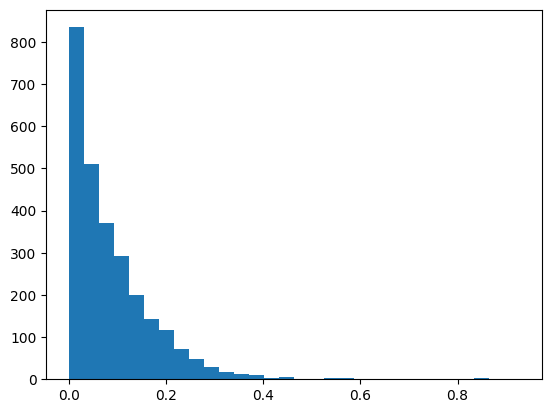

In [ ]:
import matplotlib.pyplot as plt

plt.hist(non_existing_blocks_fraction, bins=30);

In [11]:
# from pathlib import Path

# # litematic = os.listdir("../../data/web_data/litematic")

# schematics_ids = list(map(lambda x: Path(x).stem,os.listdir("../../data/web_data/schematic")))

# for file in tqdm(os.listdir("../../data/web_data/schem_all")):
#     file = Path(file)
#     if file.stem in schematics_ids:
#         os.rename("../../data/web_data/schem_all/" / file, "../../data/web_data/schem_done/" / file)
#     # print(file)

100%|██████████| 12815/12815 [00:25<00:00, 503.62it/s]


Глянуть пересечение по блокам между множествами

Сделать фильтр на число заменямых блкоов на воздух (10% грань)

Пофильтровать по минимальному объему

Глянукть сколько сэмплов умешается в 64х64х64



# Статистика по трейну

In [ ]:
import torch
import json
from pathlib import Path
import os


block_data_path = Path("../block_data/")
data_dir = Path("../../data/dataset/")

with open(block_data_path / "idx2block.json") as f:
    idx2block = json.load(f)
    
files = [data_dir / "train" / file for file in os.listdir(data_dir / "train")] + \
    [data_dir / "val" / file for file in os.listdir(data_dir / "val")] + \
    [data_dir / "train_extended" / file for file in os.listdir(data_dir / "train_extended")] + \
    [data_dir / "val_extended" / file for file in os.listdir(data_dir / "val_extended")]

In [ ]:
from tqdm import tqdm

result = {block : 0 for block in idx2block}

for file in tqdm(files):
    block_type = torch.load(file / "block_type.pt", weights_only=False)
    for idx in block_type.flatten():
        result[idx2block[idx]] += 1
        
with open("statistics.json", "w") as w:
    json.dump(result, w, indent=4)

In [1]:
import json
import matplotlib.pyplot as plt

with open("./statistics.json") as f:
    statistics = json.load(f)

statistics = list(statistics.items())

In [11]:
import numpy as np
import torch

values = torch.from_numpy(np.array([x[1] for x in statistics])).float()
values = values[values > 0]
np.sum(np.array([x[1] for x in statistics]) < 10000)

800

In [4]:
len(statistics)

973

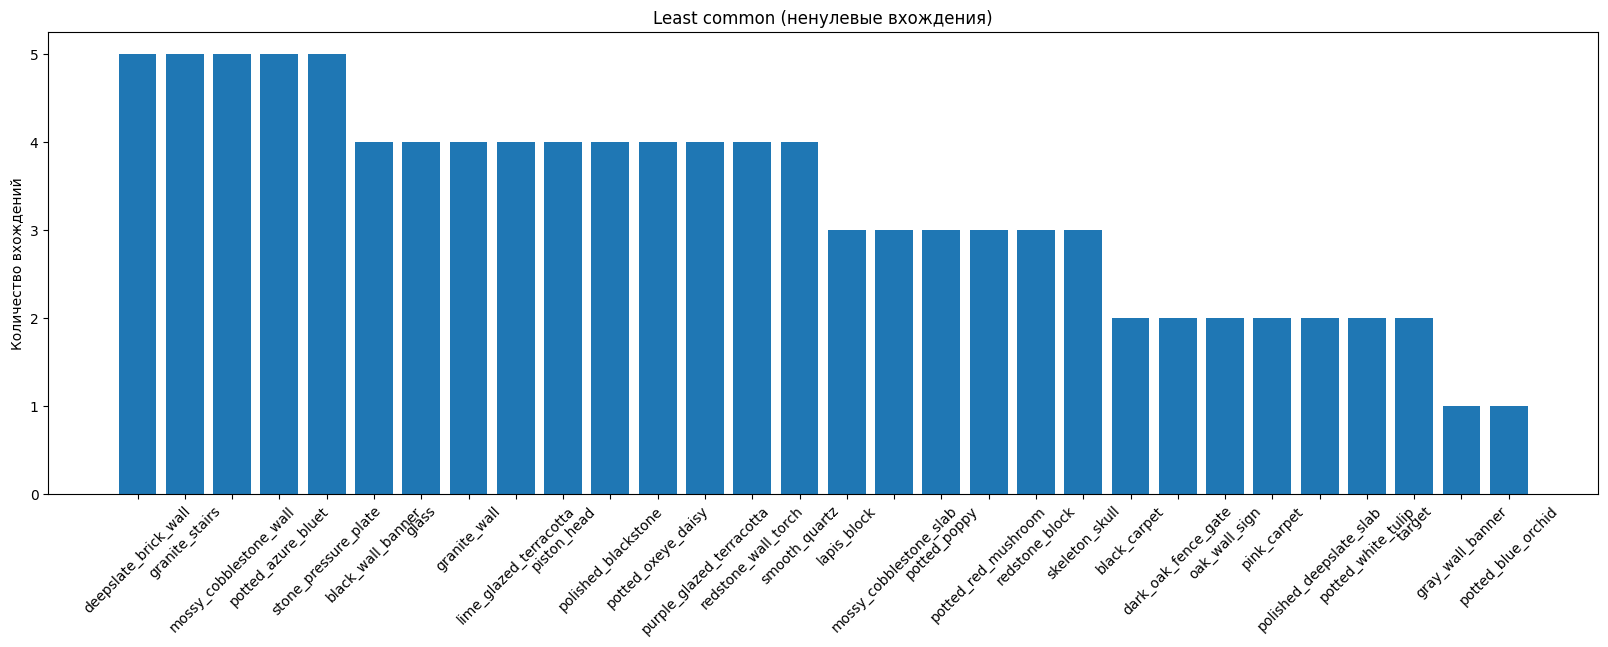

In [13]:
import numpy as np

def show_top_statistics(statistics, limit, reversed=False, nonzero=False, ax=None, title=""):
    data = sorted(statistics, key=lambda x: -x[1])

    if nonzero:
        data = [item for item in data if item[1] != 0]

    if reversed:
        data = data[-limit:]
    else:
        data = data[:limit]


    names = [item[0][item[0].index(":") + 1:] for item in data]
    values = [item[1] for item in data]

    ax.bar(np.arange(len(names)), values)
    ax.set_xticks(np.arange(len(names)), names, rotation=45)
    ax.set_title(title)
    ax.set_ylabel("Количество вхождений")
    # ax.set_yscale("log")

fig, ax = plt.subplots(1, 1, figsize=(20, 6))

# show_top_statistics(statistics, 300, reversed=True, nonzero=False, ax=ax[0], title="Least common")
show_top_statistics(statistics, 30, reversed=True, nonzero=True, ax=ax, title="Least common (ненулевые вхождения)")
# show_top_statistics(statistics, 15, reversed=False, nonzero=False, ax=ax[1], title="Most common")

In [5]:
len(values)

479

In [16]:
print(values.max())
print(values.min())
print(values.mean())
print(values.median())

tensor(2.7249e+09)
tensor(1.)
tensor(10615426.)
tensor(2046.)


tensor(10.)
tensor(0.1146)
tensor(1.8854)
tensor(1.1055)


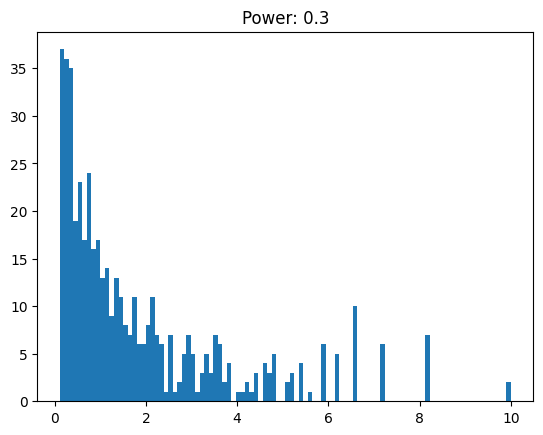

In [50]:
def make_class_weights(values, power=0.3, eps=1e-5):
    values = values.float()
    max_count = values.max()
    
    weights = (max_count / (values + eps)) ** power
    weights = weights / weights.max() * 9.9   # редчайшие классы -> 10
    return weights + 0.1

power = 0.3
w = make_class_weights(values, power=power)
print(w.max())
print(w.min())
print(w.mean())
print(w.median())
plt.hist(w, bins=100)
# plt.xscale("log")
# plt.xlim([0,2])
plt.title(f"Power: {power}");

tensor(1.0100)
tensor(0.0144)
tensor(0.2327)
tensor(0.1587)


In [ ]:
import torch

result = torch.nn.functional.softmax(values.log1p(), dim=0)

In [125]:
print(result.max())
print(result.min())
print(result.mean())
print(result.median())

tensor(0.5359)
tensor(3.9333e-10)
tensor(0.0021)
tensor(4.0257e-07)


In [138]:
print(torch.exp(1 / values).max())
print(torch.exp(1 / values).min())
print(torch.exp(1 / values).mean())
print(torch.exp(1 / values).median())

tensor(2.7183)
tensor(1.)
tensor(1.0411)
tensor(1.0005)


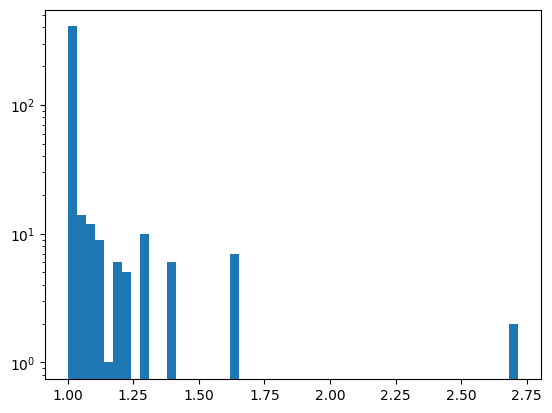

In [139]:
plt.hist(torch.exp(1 / values), bins=50, log=True);

In [126]:
# print(values.log1p().max())
# print(values.log1p().min())
# print(values.log1p().mean())
# print(values.log1p().median())

In [91]:
result2 = torch.log(1 / values.log1p())

In [92]:
print(result2.max())
print(result2.min())
print(result2.mean())
print(result2.median())

tensor(0.3665)
tensor(-3.0785)
tensor(-1.8967)
tensor(-2.0313)


In [112]:
w = ((result2 - result2.min()) / (result2.max() - result2.min())) * 3 + 0.1

In [113]:
print(w.max())
print(w.min())
print(w.mean())
print(w.median())

tensor(3.1000)
tensor(0.1000)
tensor(1.1291)
tensor(1.0119)


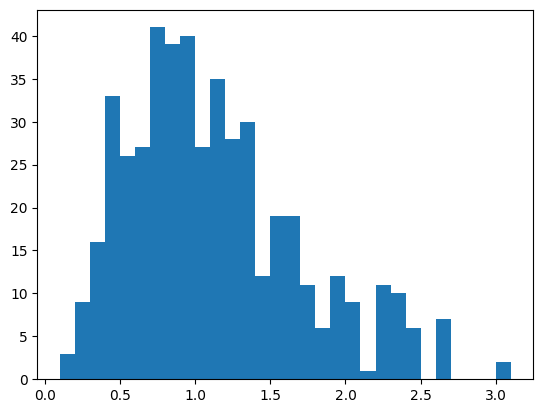

In [119]:
plt.hist(w, bins=30);

In [74]:
len(w)

479

In [75]:
torch.sum(w > 0.5)

tensor(9)

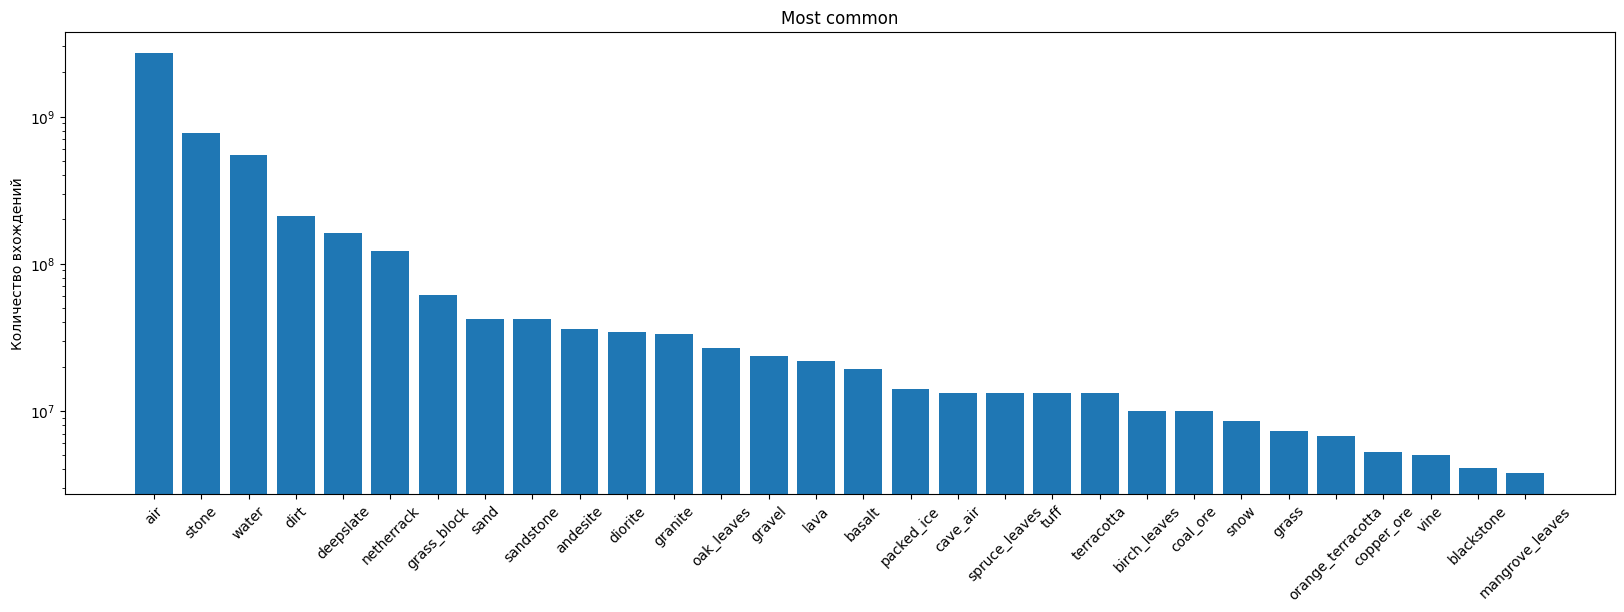

In [20]:
import numpy as np

def show_top_statistics(statistics, limit, reversed=False, nonzero=False, ax=None, title=""):
    data = sorted(statistics, key=lambda x: -x[1])

    if nonzero:
        data = [item for item in data if item[1] != 0]

    if reversed:
        data = data[-limit:]
    else:
        data = data[:limit]


    names = [item[0][item[0].index(":") + 1:] for item in data]
    values = [item[1] for item in data]

    ax.bar(np.arange(len(names)), values)
    ax.set_xticks(np.arange(len(names)), names, rotation=45)
    ax.set_title(title)
    ax.set_ylabel("Количество вхождений")
    ax.set_yscale("log")

fig, ax = plt.subplots(1, 1, figsize=(20, 6))

# show_top_statistics(statistics, 300, reversed=True, nonzero=False, ax=ax[0], title="Least common")
# show_top_statistics(statistics, 30, reversed=True, nonzero=True, ax=ax, title="Least common (ненулевые вхождения)")
show_top_statistics(statistics, 30, reversed=False, nonzero=False, ax=ax, title="Most common")